# Minnesota Food Shelf Statistical Analysis

This notebook tests the null hypothesis:

> A county's metropolitan status has no effect on its number of food shelf locations per 10,000 residents.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
county = pd.read_pickle("data/countytable.pkl")
len(county)

87

## Mean Food Shelf Count Per 10k Residents

In [food_shelf_eda.ipynb](https://github.com/a-location-1/mn-food-shelf-analysis/blob/main/food_shelf_eda.ipynb), we compiled a table of the 87 Minnesota counties and classified each one according to four metropolitan classifications:
- `3`: Twin Cities core
- `2`: Seven-county metro area
- `1`: Metropolitan Statistical Area
- `0`: Non-Metro

Our analysis will now focus on a binary Metropolitan/Non-Metropolitan split. We collapse `tcmetro` into `metro`:

In [ ]:
# Adding the binary column metro:
county["metro"] = 0
county.loc[county["tcmetro"] > 0, "metro"] = 1

There are 74 Non-Metro counties and 13 Metro counties.

The below tables emphasize that "Non-Metro" does not easily equate to "rural": St. Louis, which has its county seat in Duluth, has a larger population than 8 of the 13 Metro counties. 



In [6]:
# Displaying the largest and smallest non-metro counties:
pd.concat(
    [
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population", ascending=False)
        .head(1),
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population")
        .head(1),
    ]
)

,county,population
71,St. Louis,200794
77,Traverse,3134


In [10]:
# Displaying the 13 Metro counties:
county.loc[county["metro"] == 1, ["county", "population"]].sort_values(
    "population"
).head(13)

,county,population
47,Mille Lacs,27577
39,Le Sueur,29458
29,Isanti,43687
12,Chisago,59105
69,Sherburne,103059
9,Carver,112628
85,Wright,154593
68,Scott,157206
81,Washington,283960
1,Anoka,376840


Our initial alternative hypothesis was that Non-Metro counties have fewer food shelf locations per 10,000 residents than Metro counties.

Investigating the proportion of food shelf locations per 10,000 residents, we have good reason to think the exact opposite is true:

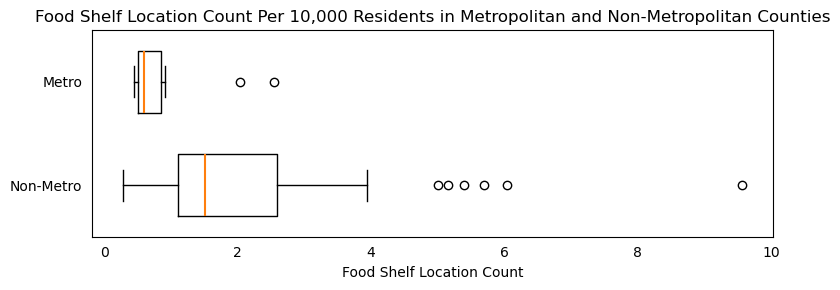

In [ ]:
# Box plots for Metro and Non-Metro food shelf location counts:
metro_status = [0, 1]
labels = ["Non-Metro", "Metro"]
plotdata = [
    county.loc[county["metro"] == status, "count_per_10k"] for status in metro_status
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(
    plotdata,
    vert=False,
    patch_artist=False,
    tick_labels=labels,
    widths=0.6,
    medianprops=dict(linewidth=1.5),
)
ax.set_title(
    "Food Shelf Location Count Per 10,000 Residents in Metropolitan and Non-Metropolitan Counties"
)
ax.set_xlabel("Food Shelf Location Count")
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.show()

Non-Metro counties have a higher proportion of food shelf locations per 10,000 residents than Metro counties. The difference is pronounced: there's no overlap between the two groups' interquartile ranges.

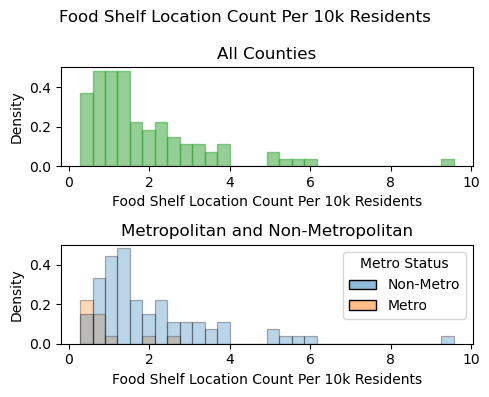

In [ ]:
bin_num = 30

fig, ax = plt.subplots(2, 1, figsize=(5, 4))
ax[0].hist(
    county["count_per_10k"],
    bins=bin_num,
    density=True,
    color="tab:green",
    edgecolor="tab:green",
    linewidth=1,
    alpha=0.5,
)
ax[0].set_title("All Counties")
ax[0].set_xlabel("Food Shelf Location Count Per 10k Residents")
ax[0].set_ylabel("Density")
ax[0].set_ylim(0, 0.5)

sns.histplot(
    data=county,
    x="count_per_10k",
    hue="metro",
    element="bars",
    stat="density",
    bins=bin_num,
    common_norm=True,
    multiple="layer",
    ax=ax[1],
)

for patch in ax[1].patches:
    patch.set_alpha(0.3)
    patch.set_linewidth(0.9)

legend = ax[1].get_legend()
for text, label in zip(legend.get_texts(), ["Non-Metro", "Metro"]):
    text.set_text(label)
ax[1].get_legend().set_title("Metro Status")

ax[1].set_title("Metropolitan and Non-Metropolitan")
ax[1].set_xlabel("Food Shelf Location Count Per 10k Residents")
ax[1].set_ylabel("Density")
ax[1].set_ylim(0, 0.5)

plt.suptitle("Food Shelf Location Count Per 10k Residents")
plt.tight_layout()
plt.show()

In [100]:
(county["count_per_10k"] <= 2).mean()

np.float64(0.6551724137931034)

Across all counties the distribution is sharply right-skewed, with most of the values (65%) falling between 0 and 2.

Nevertheless, the difference between the Metro and Non-Metro distributions is stark: the bulk of the Metro values seem to cluster below 1.0, and the Non-Metro values are densest around 1.5 and above.

In [83]:
pd.concat(
    [
        county.groupby("metro").agg({"count": ["mean", "median"]}),
        county.groupby("metro").agg({"count_per_10k": ["mean", "median"]}),
    ],
    axis=1,
).rename(index={0: "Non-Metro", 1: "Metro"}).round(4)

count        count_per_10k        
              mean median          mean  median
metro                                          
Non-Metro   4.1351    3.0        2.0731  1.5047
Metro      18.6923    7.0        0.8706  0.5987

Non-Metro counties have more than double the average number of locations (2.07 count per 10k versus 0.87 count per 10k).

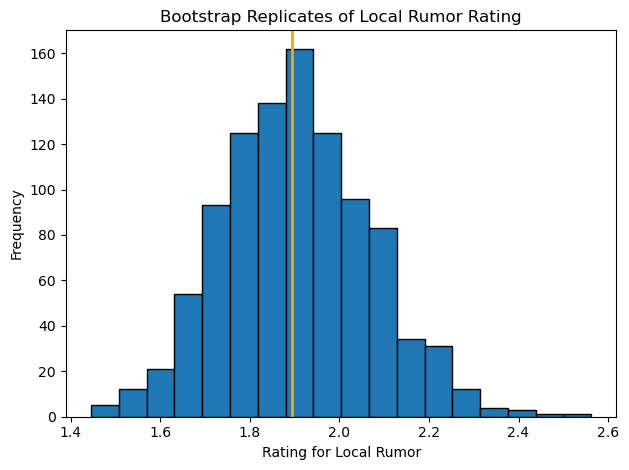

In [98]:
# Bootstrapping confidence intervals:
replicates = []
for _ in range(1_000):
    replicates.append(county.sample(frac=1, replace=True)["count_per_10k"].mean())

plt.hist(replicates, bins=18, edgecolor="black")
plt.axvline(county["count_per_10k"].mean(), color="orange", linestyle="-", linewidth=2)
plt.xlabel("Rating for Local Rumor")
plt.ylabel("Frequency")
plt.title("Bootstrap Replicates of Local Rumor Rating")
plt.tight_layout()
plt.show()

## Testing Count Per 10k

Is this statistically significant?

To test this further, we'll investigate the difference between the Non-Metro mean food shelf location count per 10k minus the Metro mean food shelf location count per 10k.

In [84]:
def difference_in_means(df):
    means = df.groupby("metro")["count_per_10k"].mean()
    return np.round(means[0] - means[1], 4)

In [85]:
observed_value = difference_in_means(county)
print(f"Observed value: {observed_value}")

Observed value: 1.2025


In [86]:
replicates = [observed_value]
n_sim = 20_000
sim_county = county.copy()

for _ in range(n_sim - 1):
    sim_county["metro"] = (
        sim_county["metro"].sample(frac=1, replace=False).reset_index(drop=True)
    )
    replicates.append(difference_in_means(sim_county))

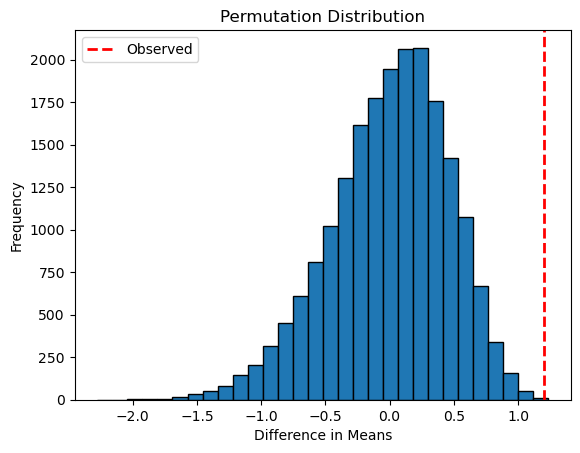

In [87]:
plt.hist(replicates, bins=30, edgecolor="black")
plt.axvline(observed_value, color="red", linestyle="--", linewidth=2, label="Observed")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.title("Permutation Distribution")
plt.legend()
plt.show()

In [88]:
p_value = np.mean(np.abs(replicates) >= np.abs(observed_value))
p_value

np.float64(0.01065)

In [89]:
pd.Series(replicates).skew()

np.float64(-0.4727610787419412)

## Analyzing Relationship Between Metropolitanism and Food Shelf Location Counts